# Part 1a: L1 & L2 Regularization — A/B Test
**Author:** Kalhar Mayurbhai Patel (019140511)

This notebook demonstrates L1 and L2 regularization in both TensorFlow/Keras and PyTorch.
We compare a baseline (no regularization) against L1, L2, and ElasticNet models on a synthetic dataset.

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## Generate Synthetic Data

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=2000, n_features=20, n_informative=10,
                           n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1400, 20), Test: (600, 20)


## TensorFlow / Keras Section

We build 4 models:
1. **Baseline** — no regularization
2. **L1** — penalizes absolute weight values (promotes sparsity)
3. **L2** — penalizes squared weight values (keeps weights small)
4. **ElasticNet (L1+L2)** — combination of both

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

def build_tf_model(reg=None, name="model"):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', kernel_regularizer=reg, input_shape=(20,)),
        layers.Dense(32, activation='relu', kernel_regularizer=reg),
        layers.Dense(1, activation='sigmoid')
    ], name=name)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Create models with different regularizations
configs = {
    'Baseline': None,
    'L1 (0.001)': regularizers.l1(0.001),
    'L2 (0.001)': regularizers.l2(0.001),
    'ElasticNet': regularizers.l1_l2(l1=0.001, l2=0.001),
}

tf_histories = {}
for label, reg in configs.items():
    print(f"\nTraining: {label}")
    m = build_tf_model(reg, name=label.replace(" ", "_").replace("(","").replace(")",""))
    h = m.fit(X_train, y_train, epochs=50, batch_size=32,
              validation_data=(X_test, y_test), verbose=0)
    tf_histories[label] = h.history
    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f"  Test Accuracy: {acc:.4f}  |  Test Loss: {loss:.4f}")


Training: Baseline


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test Accuracy: 0.9367  |  Test Loss: 0.2973

Training: L1 (0.001)
  Test Accuracy: 0.9467  |  Test Loss: 0.2981

Training: L2 (0.001)
  Test Accuracy: 0.9350  |  Test Loss: 0.2923

Training: ElasticNet
  Test Accuracy: 0.9450  |  Test Loss: 0.2908


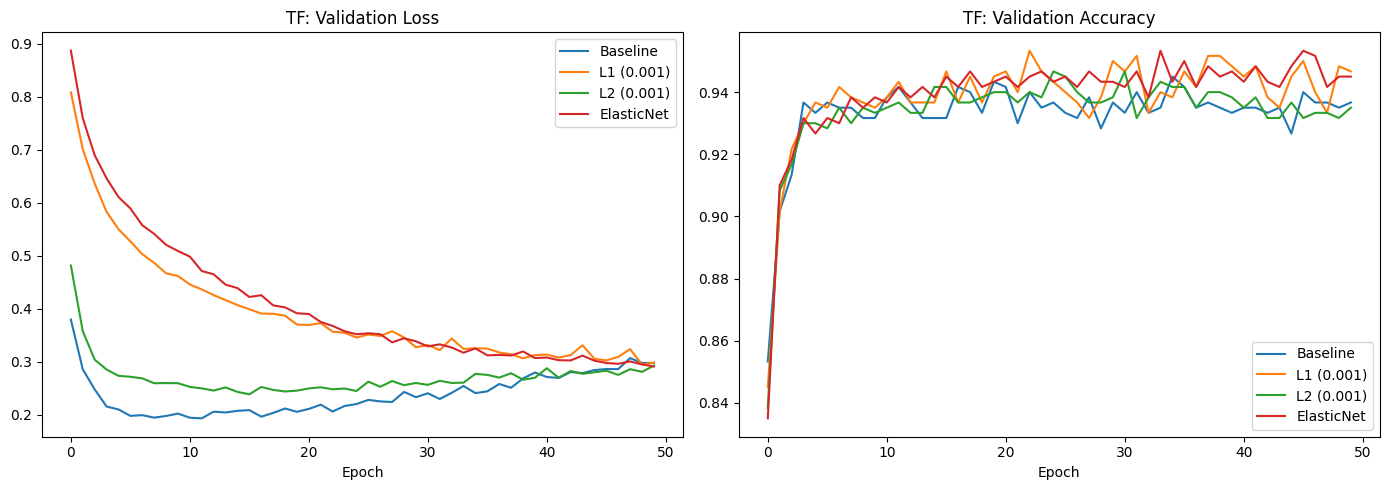

In [4]:
# Plot A/B comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, hist in tf_histories.items():
    axes[0].plot(hist['val_loss'], label=label)
    axes[1].plot(hist['val_accuracy'], label=label)
axes[0].set_title('TF: Validation Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].set_title('TF: Validation Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

## PyTorch Section

Same experiment replicated in PyTorch. We manually add L1/L2 penalty to the loss.

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_tr_t = torch.FloatTensor(X_train).to(device)
y_tr_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_te_t = torch.FloatTensor(X_test).to(device)
y_te_t = torch.FloatTensor(y_test).unsqueeze(1).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

def train_pt(model, reg_type=None, lam=0.001, epochs=50):
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.BCELoss()
    val_losses, val_accs = [], []
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_dl:
            pred = model(xb)
            loss = criterion(pred, yb)
            # Add regularization manually
            if reg_type == 'l1':
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += lam * l1_norm
            elif reg_type == 'l2':
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss += lam * l2_norm
            elif reg_type == 'elastic':
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss += lam * (l1_norm + l2_norm)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        # Validate
        model.eval()
        with torch.no_grad():
            vp = model(X_te_t)
            vl = criterion(vp, y_te_t).item()
            va = ((vp > 0.5).float() == y_te_t).float().mean().item()
        val_losses.append(vl); val_accs.append(va)
    return val_losses, val_accs

pt_results = {}
for label, rtype in [('Baseline', None), ('L1', 'l1'), ('L2', 'l2'), ('ElasticNet', 'elastic')]:
    torch.manual_seed(42)
    model = SimpleNet().to(device)
    vl, va = train_pt(model, reg_type=rtype)
    pt_results[label] = (vl, va)
    print(f"{label}: Final Val Acc={va[-1]:.4f}, Val Loss={vl[-1]:.4f}")

Baseline: Final Val Acc=0.9383, Val Loss=0.4665
L1: Final Val Acc=0.9467, Val Loss=0.1894
L2: Final Val Acc=0.9350, Val Loss=0.2404
ElasticNet: Final Val Acc=0.9433, Val Loss=0.1869


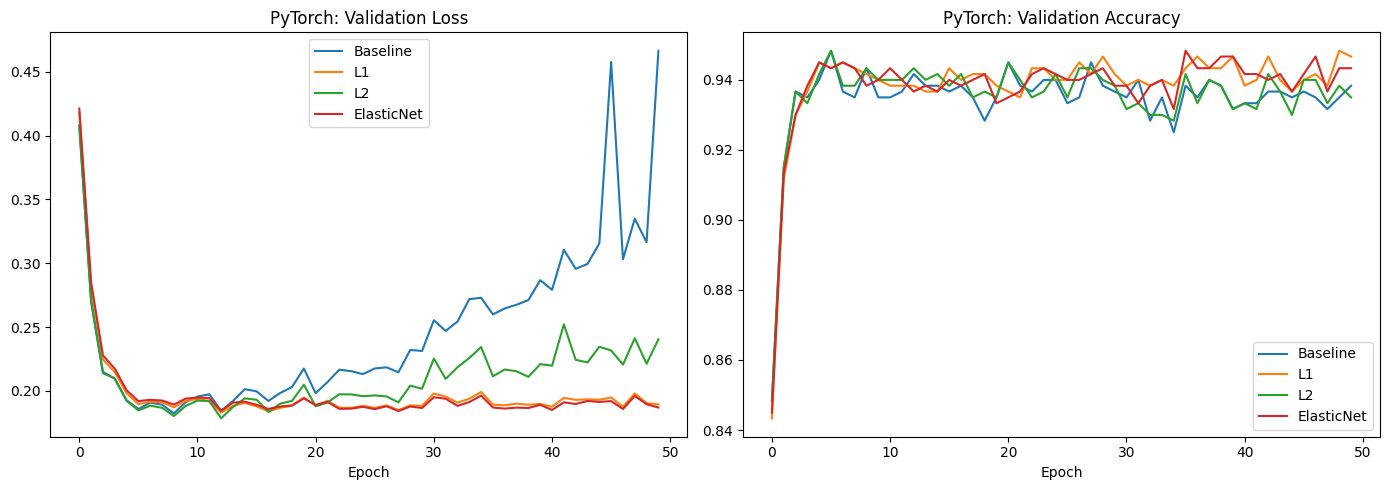

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, (vl, va) in pt_results.items():
    axes[0].plot(vl, label=label)
    axes[1].plot(va, label=label)
axes[0].set_title('PyTorch: Validation Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].set_title('PyTorch: Validation Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

## Key Takeaways
- **L1** pushes many weights to exactly 0 → feature selection / sparsity
- **L2** distributes penalty evenly → smaller but non-zero weights
- **ElasticNet** combines benefits of both
- Without regularization, the model tends to overfit more on small/noisy datasets